# Pyramid Chart

A pyramid chart compares two groups over the same ordered categories: the first group extends to the left of a shared zero line, the second to the right, and the shape they make together (a wide base, a bulge, a lopsided top) is the message. It is the classic age-sex population pyramid, and it serves any paired comparison over ordered categories, such as arrivals against departures by hour. This guide shows how to create pyramid charts with the [datachart.charts.PyramidChart](../../../references/charts/pyramidchart/#datachart.charts.PyramidChart) function, starting with the basics and building up to worked examples on real data.

Looking for a specific customization? Jump straight to the [quick reference](#customizing-the-pyramid-chart), which maps common tasks to the parameter or style attribute that does the job.

In [1]:
from datachart.charts import PyramidChart

## Basics

The examples in this guide share one dataset: the illustrative age structure of a country of about ten million people, by sex and five-year age band, in thousands. The figures are hand-written to show the shape of an ageing population (a baby-boom bulge now aged 55 to 64, smaller cohorts below it, and a top where women outnumber men two to one); they are not the census of any real country. The data lives in a hidden cell: `AGE_BANDS` lists the eighteen bands from `0-4` to `85+`, and `men` and `women` hold one data point per band for each sex.

In [2]:
# an illustrative ageing population of about ten million, by sex and five-year age band (thousands)
AGE_BANDS = [f"{age}-{age + 4}" for age in range(0, 85, 5)] + ["85+"]
MEN = [230, 245, 260, 265, 270, 290, 320, 340, 335, 330, 355, 370, 350, 300, 260, 180, 110, 60]
WOMEN = [218, 232, 247, 252, 258, 280, 312, 335, 333, 332, 360, 380, 368, 330, 305, 235, 170, 130]

men = [{"label": band, "y": count} for band, count in zip(AGE_BANDS, MEN)]
women = [{"label": band, "y": count} for band, count in zip(AGE_BANDS, WOMEN)]
SIDES = ["Men", "Women"]

Each data point is a dictionary with a `label` (the age band) and a positive `y` value; the same labels appear on both sides, in the same order:

In [3]:
men[:3]

[{'label': '0-4', 'y': 230},
 {'label': '5-9', 'y': 245},
 {'label': '10-14', 'y': 260}]

**Basic example.** Only the `data` argument is required: exactly two lists of data points, the first drawn to the left and the second to the right. Both sides are given as positive values, the chart mirrors the left side itself, and the value ticks read as positive on both halves. The first band is drawn at the bottom, so the youngest cohort forms the base:

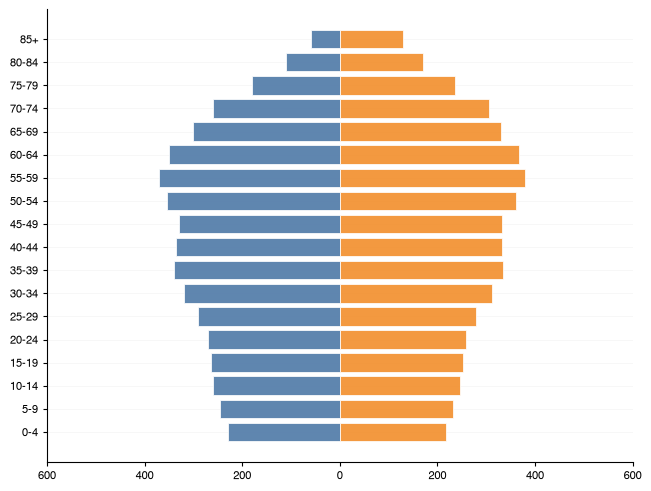

In [4]:
PyramidChart(
    # the two sides of the pyramid: [left_side, right_side]
    data=[men, women]
).show()

## Customizing the Pyramid Chart

Every customization is either a keyword argument of `PyramidChart` or a `plot_bar_*` attribute of its `style` dictionary. The table maps common tasks to the one you need and links to the subsection that shows it.

| I want to…                                     | Use                                                                 | See |
| :--------------------------------------------- | :------------------------------------------------------------------ | :-- |
| add a title and axis labels                    | `title`, `xlabel`, `ylabel`                                         | [Title and axis labels](#title-and-axis-labels) |
| name the two sides and show the legend         | `subtitle`, `show_legend`, `legend`                                 | [Naming the sides](#naming-the-sides) |
| resize the figure or show grid lines           | `figsize`, `show_grid`                                              | [Figure size and grid](#figure-size-and-grid) |
| fix the value range or format the value ticks  | `xmax`, `xticks`, `xticklabels`, `xticks_format`, `xtickrotate`     | [Value axis range and ticks](#value-axis-range-and-ticks) |
| thin out or relabel the category ticks         | `yticks`, `yticklabels`, `ytickrotate`                              | [Category ticks](#category-ticks) |
| print the value at the end of each bar         | `show_values`, `value_format`                                       | [Value labels](#value-labels) |
| change the bar color, hatch, or edge, per side | `style`                                                             | [Bar style](#bar-style) |
| rank the categories by size                    | `sort`, `sort_by`                                                   | [Sorting](#sorting) |
| highlight some bars, mute the rest             | `emphasis_rule`, the `"emphasis"` key of a data point               | [Emphasis](#emphasis) |
| mark a value or an age boundary                | `vlines`, `hlines`, `dlines`                                       | [Reference lines and bands](#reference-lines-and-bands) |
| shade a value range or a run of bands          | `vspans`, `hspans`                                                  | [Reference lines and bands](#reference-lines-and-bands) |
| put a note on the chart                        | `texts`                                                             | [Text annotations](#text-annotations) |
| put several pyramids side by side              | `Grid`                                                              | [Multiple Pyramid Charts](#multiple-pyramid-charts) |
| show the uncertainty of each bar               | `yerr` in `data`, `show_yerr`                                       | [Error bars](#error-bars) |
| use times or dates as category labels          | `datetime` objects as `label`, `yticks_format`                      | [Date labels](#date-labels) |
| plot data with other key names                 | `label`, `y`, `yerr`                                                | [Custom data keys](#custom-data-keys) |
| save the chart to a file                       | `save_figure`                                                       | [Saving Figures](../../utility/saving/) guide |

The parameters that accept a constant, with the class in [datachart.constants](../../../references/constants/) that lists its values:

| Parameter | Constant |
| :-- | :-- |
| `xticks_format` | [`VALUE_FORMAT`](../../../references/constants/#datachart.constants.VALUE_FORMAT), [`DATE_FORMAT`](../../../references/constants/#datachart.constants.DATE_FORMAT) |
| `figsize` | [`FIG_SIZE`](../../../references/constants/#datachart.constants.FIG_SIZE) |
| `legend={"location": ..., "alignment": ...}` | [`LEGEND_LOCATION`](../../../references/constants/#datachart.constants.LEGEND_LOCATION), [`LEGEND_ALIGN`](../../../references/constants/#datachart.constants.LEGEND_ALIGN) |
| `show_grid` | [`SHOW_GRID`](../../../references/constants/#datachart.constants.SHOW_GRID) |
| `value_format` | [`VALUE_FORMAT`](../../../references/constants/#datachart.constants.VALUE_FORMAT) |
| `sort` | [`SORT`](../../../references/constants/#datachart.constants.SORT) |
| `yticks_format` | [`VALUE_FORMAT`](../../../references/constants/#datachart.constants.VALUE_FORMAT), [`DATE_FORMAT`](../../../references/constants/#datachart.constants.DATE_FORMAT) |

The full list of style attributes is in the [datachart.typings.BarStyleAttrs](../../../references/charts/barchart/#datachart.typings.BarStyleAttrs) type; the full list of parameters is in the [datachart.charts.PyramidChart](../../../references/charts/pyramidchart/#datachart.charts.PyramidChart) reference.

### Title and axis labels

A pyramid without labels is a shape; the title and the axis labels say what it measures and in what units. Unlike the other charts, the axis parameters of a pyramid are spatial: `xlabel` describes the horizontal value axis (the population of a band) and `ylabel` the vertical category axis (the age bands).

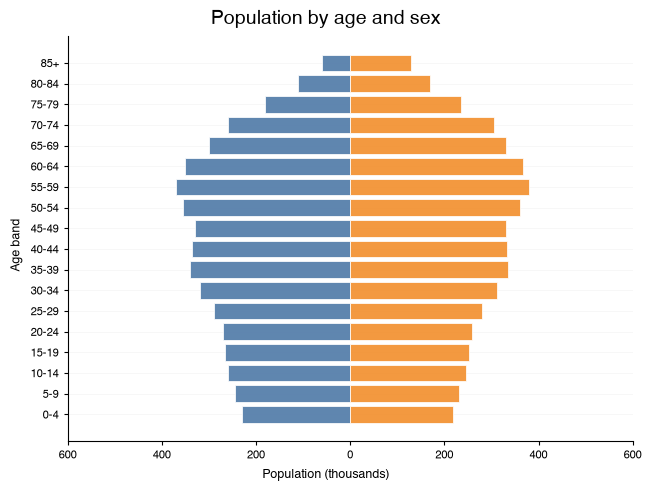

In [5]:
PyramidChart(
    data=[men, women],
    # add the title
    title="Population by age and sex",
    # the value axis runs horizontally, the category axis vertically
    xlabel="Population (thousands)",
    ylabel="Age band",
).show()

### Naming the sides

Nothing on the chart says which side is which until the sides are named. `subtitle` takes the two names in the order of `data`, and `show_legend` puts them in the legend. `legend` then says where and how: a `title`, a `location` from [LEGEND_LOCATION](../../../references/constants/#datachart.constants.LEGEND_LOCATION), the number of columns `ncols` and the `alignment` of the entries from [LEGEND_ALIGN](../../../references/constants/#datachart.constants.LEGEND_ALIGN); a field left out falls back to the theme ([LegendSettingAttrs](../../../references/typings/#datachart.typings.LegendSettingAttrs)). The top corners of an ageing pyramid are empty, so the legend fits in one of them.

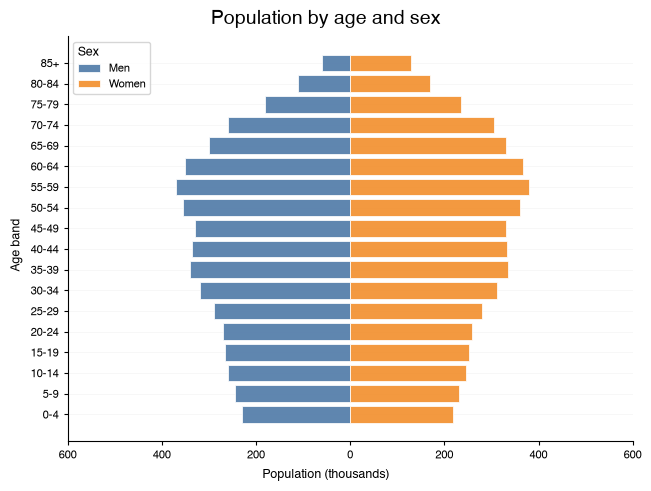

In [6]:
from datachart.constants import LEGEND_LOCATION

PyramidChart(
    data=[men, women],
    # name the sides, in the order of the data
    subtitle=SIDES,
    # show them in a titled legend, in the empty upper-left corner
    show_legend=True,
    legend={"title": "Sex", "location": LEGEND_LOCATION.UPPER_LEFT},
    title="Population by age and sex",
    xlabel="Population (thousands)",
    ylabel="Age band",
).show()

### Figure size and grid

Eighteen bands per side need vertical room, or the bars turn into thin stripes. `figsize` takes a `(width, height)` tuple in inches or one of the presets in [datachart.constants.FIG_SIZE](../../../references/constants/#datachart.constants.FIG_SIZE); a tall preset gives every band a readable bar. Grid lines let the eye carry the end of a bar down to the value axis, on either half: `show_grid` draws them along the value axis with [SHOW_GRID.X](../../../references/constants/#datachart.constants.SHOW_GRID) (`SHOW_GRID.Y` and `SHOW_GRID.BOTH` are the other options).

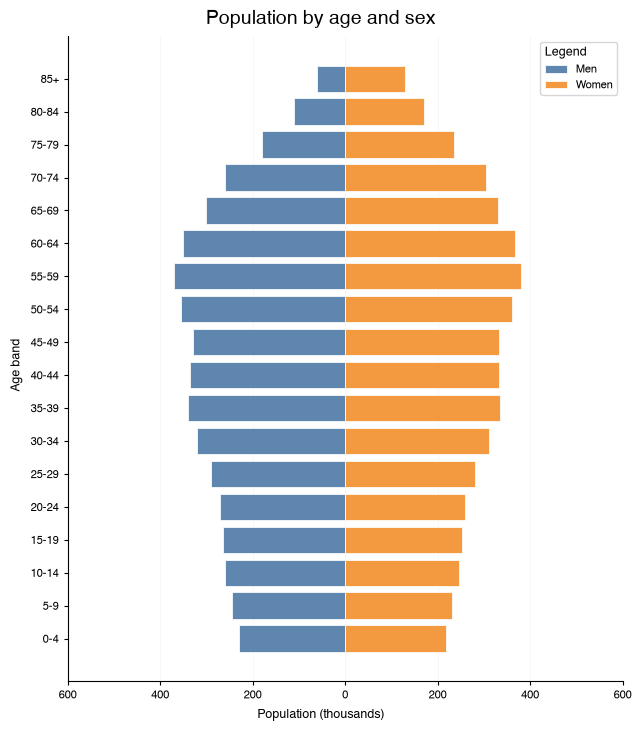

In [7]:
from datachart.constants import FIG_SIZE, SHOW_GRID

PyramidChart(
    data=[men, women],
    subtitle=SIDES,
    show_legend=True,
    title="Population by age and sex",
    xlabel="Population (thousands)",
    ylabel="Age band",
    # a tall figure, one readable bar per band
    figsize=FIG_SIZE.FULL_TALL,
    # grid lines along the value axis, on both halves
    show_grid=SHOW_GRID.X,
).show()

### Value axis range and ticks

The value axis is always symmetric around zero, so the two sides compare at a glance; `xmax` sets the per-side maximum and the axis spans `(-xmax, xmax)`. Passing `xmin` raises a `ValueError`. A fixed `xmax` matters when two pyramids are read against each other: it gives them the same scale. Give `xticks` along with it, ending on `xmax`, so the axis ends on a labeled tick. `xticks` places the value ticks, as positive positions mirrored to both halves, and `xticks_format` formats them ([VALUE_FORMAT](../../../references/constants/#datachart.constants.VALUE_FORMAT) or any `"{x:.0f}"` style string, applied to the absolute value); `xticklabels` replaces the labels outright when a format string cannot produce them, and `xtickrotate` tilts them. The counts are in thousands, and a `k` suffix says so without an axis label.

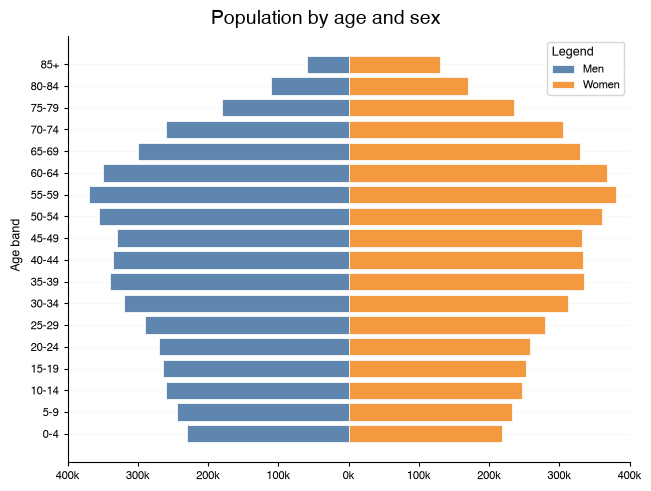

In [8]:
PyramidChart(
    data=[men, women],
    subtitle=SIDES,
    show_legend=True,
    title="Population by age and sex",
    ylabel="Age band",
    # the axis spans -400 to 400, with a tick every 100 on both halves
    xmax=400,
    xticks=[0, 100, 200, 300, 400],
    # the ticks read as absolute values, here with a thousands suffix
    xticks_format="{x:.0f}k",
).show()

### Category ticks

Eighteen band labels are a lot to read, and a demographer's pyramid is usually labeled by age, not by band. `yticks` picks the category positions to label (the bands are numbered from the bottom, `0`, `1`, `2`, …), `yticklabels` gives them new text, and `ytickrotate` tilts them when they are long. Labeling every second band with the age it starts at turns the band axis into an age axis:

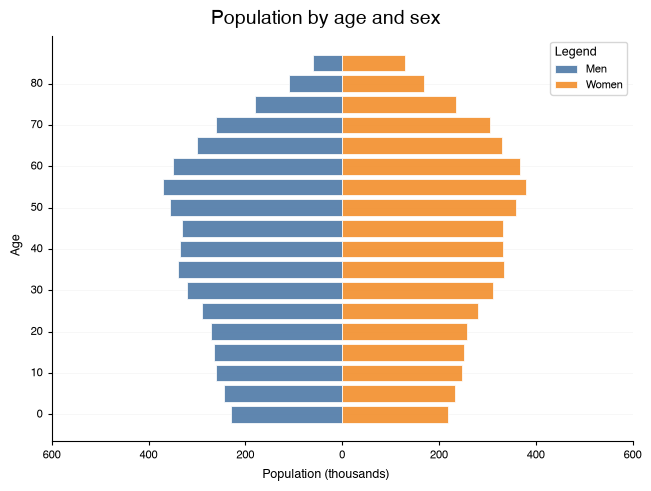

In [9]:
PyramidChart(
    data=[men, women],
    subtitle=SIDES,
    show_legend=True,
    title="Population by age and sex",
    xlabel="Population (thousands)",
    ylabel="Age",
    # every second band, labeled by the age it starts at
    yticks=list(range(0, 18, 2)),
    yticklabels=[str(age) for age in range(0, 90, 10)],
).show()

### Value labels

When the exact size of a cohort matters, `show_values` prints it at the end of each bar, as a positive number on both sides, and `value_format` formats it: a [VALUE_FORMAT](../../../references/constants/#datachart.constants.VALUE_FORMAT) constant or any `"{x:.1f}"`, `"{:.1f}%"` or `"%g"` style string. The label font size and padding are the `plot_value_*` style attributes ([ValueLabelStyleAttrs](../../../references/typings/#datachart.typings.ValueLabelStyleAttrs)). Thirty-six labels need a tall figure and a small font, and the axis is widened a little so the labels of the longest bars stay inside it.

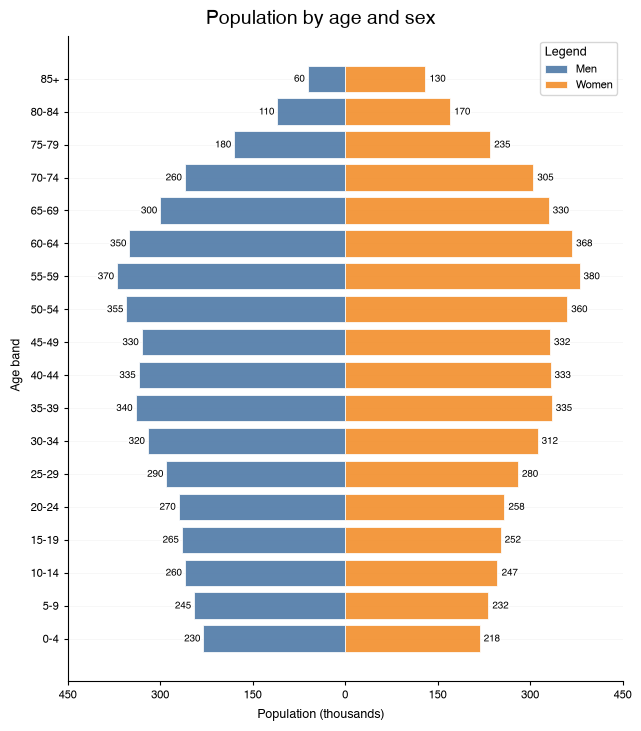

In [10]:
from datachart.constants import VALUE_FORMAT

PyramidChart(
    data=[men, women],
    subtitle=SIDES,
    show_legend=True,
    # a small font for thirty-six labels
    style={"plot_value_fontsize": 7},
    title="Population by age and sex",
    xlabel="Population (thousands)",
    ylabel="Age band",
    figsize=FIG_SIZE.FULL_TALL,
    # room for the labels past the longest bars
    xmax=450,
    xticks=[0, 150, 300, 450],
    # print the size of each cohort at the end of its bar
    show_values=True,
    value_format=VALUE_FORMAT.INTEGER,
).show()

### Bar style

Pyramid bars take the same `plot_bar_*` style attributes as the bar chart: the color and alpha, the width as a fraction of the band, the hatch pattern and the edge ([BarStyleAttrs](../../../references/charts/barchart/#datachart.typings.BarStyleAttrs)); an attribute left out keeps the value of the active theme. One `style` dictionary applies to both sides; a list of two styles them individually, which is how a printed pyramid keeps its sides apart without color: one side filled, the other hatched with a pattern from [HATCH_STYLE](../../../references/constants/#datachart.constants.HATCH_STYLE), both with a dark edge. Without explicit colors the sides take the first two colors of the theme's palette.

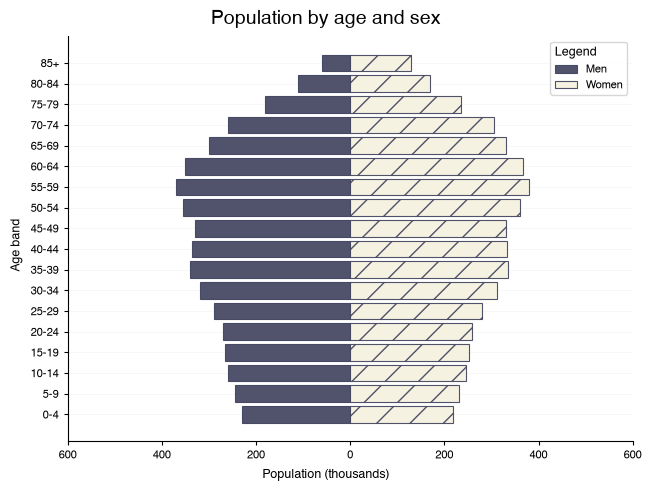

In [11]:
from datachart.constants import HATCH_STYLE

PyramidChart(
    data=[men, women],
    subtitle=SIDES,
    show_legend=True,
    # a print-safe look: one side filled, the other hatched, both edged
    style=[
        {"plot_bar_color": "#3d405b", "plot_bar_edge_color": "#3d405b", "plot_bar_edge_width": 0.8},
        {
            "plot_bar_color": "#f4f1de",
            "plot_bar_hatch": HATCH_STYLE.DIAGONAL,
            "plot_bar_edge_color": "#3d405b",
            "plot_bar_edge_width": 0.8,
        },
    ],
    title="Population by age and sex",
    xlabel="Population (thousands)",
    ylabel="Age band",
).show()

### Sorting

Age bands have a natural order, and a pyramid usually keeps it. But the same chart serves paired comparisons with no natural order, and even age bands are sometimes worth ranking to read off the largest cohorts. `sort` orders the categories by value, one order for both sides, keyed by the total of the two ([SORT](../../../references/constants/#datachart.constants.SORT)); `sort_by` keys it on one side instead, named by its `subtitle`. The first category is drawn at the bottom, so `SORT.DESCENDING` puts the largest band at the base and `SORT.ASCENDING` at the top. Ranked by the number of women, the three baby-boom bands come first, and the cohort being born now (0-4) ranks below every band up to 75-79: this population has fewer young children than adults of any working age.

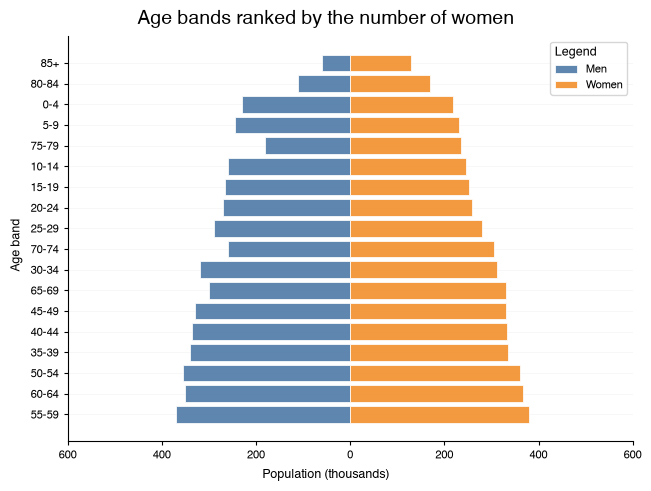

In [12]:
from datachart.constants import SORT

PyramidChart(
    data=[men, women],
    subtitle=SIDES,
    show_legend=True,
    title="Age bands ranked by the number of women",
    xlabel="Population (thousands)",
    ylabel="Age band",
    # one order for both sides, keyed by one of them; the largest at the base
    sort=SORT.DESCENDING,
    sort_by="Women",
).show()

### Emphasis

A pyramid usually makes one point, and emphasis makes it visible. `emphasis_rule` picks the bars from the data: a one-key dictionary, `{"above": v}` or `{"below": v}` (strict), `{"between": (lo, hi)}` (inclusive), `{"top": n}` or `{"bottom": n}`, read against each bar's positive value on both sides; the bars that match are highlighted and the rest muted. The roles are the [EMPHASIS](../../../references/constants/#datachart.constants.EMPHASIS) constants, and the [Highlighting](../../styling/highlighting/) guide covers emphasis across every chart type and theme. Every bar above 345 thousand belongs to the three baby-boom bands, on both sides:

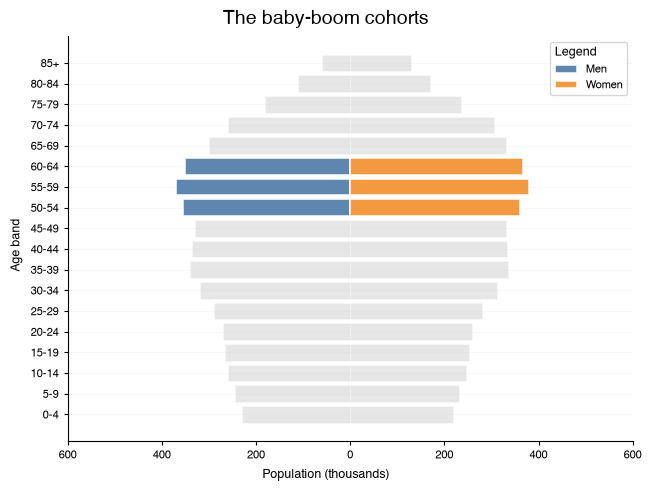

In [13]:
PyramidChart(
    data=[men, women],
    subtitle=SIDES,
    show_legend=True,
    title="The baby-boom cohorts",
    xlabel="Population (thousands)",
    ylabel="Age band",
    # every bar above 345 thousand, either side
    emphasis_rule={"above": 345},
).show()

A data point can also carry its own `"emphasis"` key (`"highlight"` or `"background"`), which wins over the rule. Tagging by hand is the way to make a point the values alone do not select: the two oldest bands on the women's side, with everything else muted, say that the very old are mostly women.

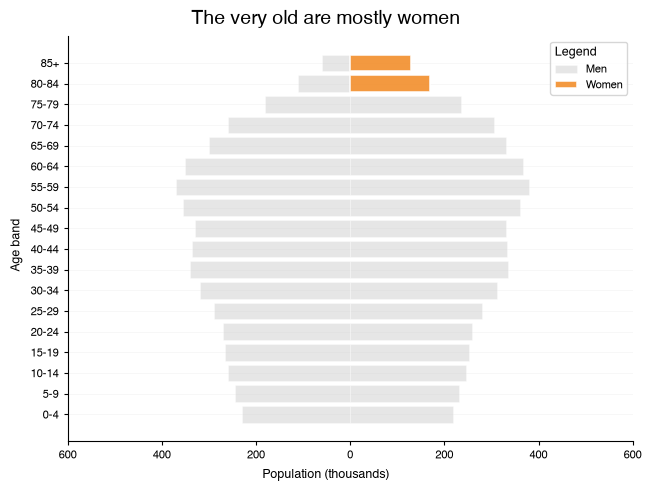

In [14]:
# highlight the two oldest bands of women, mute everything else
oldest_women = [
    {**point, "emphasis": "highlight" if point["label"] in ("80-84", "85+") else "background"}
    for point in women
]
men_muted = [{**point, "emphasis": "background"} for point in men]

PyramidChart(
    data=[men_muted, oldest_women],
    subtitle=SIDES,
    show_legend=True,
    title="The very old are mostly women",
    xlabel="Population (thousands)",
    ylabel="Age band",
).show()

### Reference lines and bands

Reference lines and bands put the bars in context. `vlines` draws a vertical line at a value and `hlines` a horizontal one at a category position; the bands are numbered from the bottom, so a half-integer position sits between two bands. `vspans` and `hspans` shade a range instead: a range of values, or a run of bands. Each takes a dictionary or a list of them, with the position, an optional `label` for the legend and a `style`; the keys are listed in [VLineSettingAttrs](../../../references/typings/#datachart.typings.VLineSettingAttrs), [HLineSettingAttrs](../../../references/typings/#datachart.typings.HLineSettingAttrs), [VSpanSettingAttrs](../../../references/typings/#datachart.typings.VSpanSettingAttrs) and [HSpanSettingAttrs](../../../references/typings/#datachart.typings.HSpanSettingAttrs).

Two things are particular to the pyramid. The value axis is mirrored, so a line on the left half sits at a negative `x`. And a single line applies to both sides and is drawn once per side, which doubles its legend entry; a list aligned with `data`, with the lines on the first side and `None` on the second, draws each line once. Bands are drawn once whichever way they are given. The example draws the size of the youngest cohort up through each side (every band from 5-9 to 70-74 is larger than the cohort being born now), marks the retirement age between the 60-64 and 65-69 bands, and shades the working-age bands from 15-19 to 60-64.

`dlines` completes the trio. Where `vlines` fixes an x and `hlines` a y, a diagonal is fixed by a `slope` and an `intercept`, so it runs through the data space instead of across it; `dlines={}` on its own draws the parity line `y = x`. It spans the axes unless `xmin` and `xmax` clip it to a segment, and takes the same optional `label` and `style`; the keys are listed in [DLineSettingAttrs](../../../references/typings/#datachart.typings.DLineSettingAttrs). The bands sit at `0`, `1`, `2`, … up the category axis and the bars carry the population, so a diagonal asks whether the pyramid tapers evenly: the line runs from the youngest band to the 60–64 band on the women's side, and the bands that reach past it are the bulges in the population.

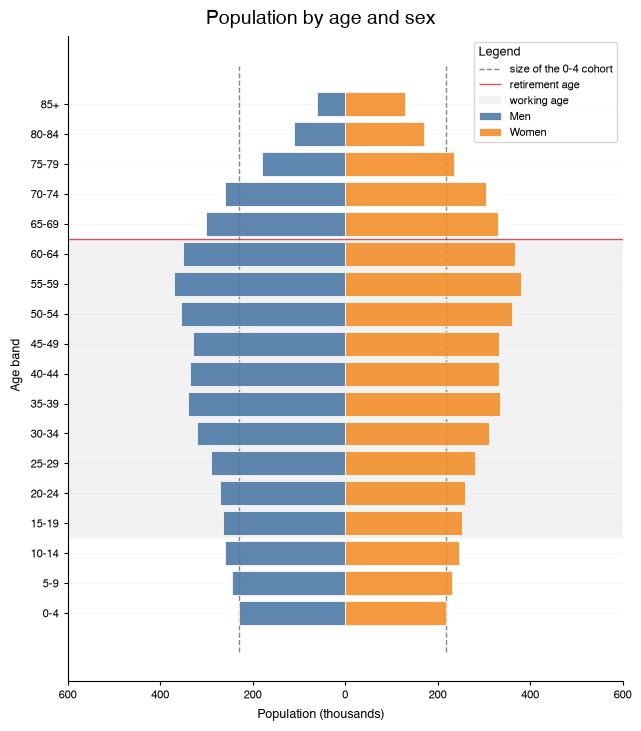

In [15]:
from datachart.constants import LINE_STYLE

DASHED = {"plot_vline_style": LINE_STYLE.DASHED, "plot_vline_color": "#555555"}

PyramidChart(
    data=[men, women],
    subtitle=SIDES,
    show_legend=True,
    # the size of the youngest cohort on each side; the left half is negative
    vlines=[
        [
            {"x": -MEN[0], "label": "size of the 0-4 cohort", "style": DASHED},
            {"x": WOMEN[0], "style": DASHED},
        ],
        None,
    ],
    # the retirement age, between the 60-64 (index 12) and 65-69 (index 13) bands
    hlines=[{"y": 12.5, "label": "retirement age", "style": {"plot_hline_color": "#c1121f"}}, None],
    # the working-age bands, 15-19 (index 3) to 60-64 (index 12)
    hspans={"ymin": 2.5, "ymax": 12.5, "label": "working age"},
    title="Population by age and sex",
    xlabel="Population (thousands)",
    ylabel="Age band",
    figsize=FIG_SIZE.FULL_TALL,
).show()

In [ ]:
TOP_BAND = 12  # the 60-64 band
# an even taper from the youngest band to it: bands per thousand women
bands_per_thousand = TOP_BAND / (WOMEN[TOP_BAND] - WOMEN[0])

PyramidChart(
    data=[men, women],
    subtitle=SIDES,
    # the line the bands would end on if the taper were even
    dlines={
        "slope": bands_per_thousand,
        "intercept": -bands_per_thousand * WOMEN[0],
        "xmin": 0,
        "label": "even taper",
        "style": {"plot_dline_color": "#1d3557", "plot_dline_style": LINE_STYLE.DASHED},
    },
    title="Population by age and sex against an even taper",
    xlabel="Population (thousands)",
    ylabel="Age band",
    figsize=FIG_SIZE.FULL_TALL,
    show_legend=True,
).show()

### Text annotations

Where a highlight shows the point, a note explains it. `texts` places text on the chart, with an optional `target` to draw a connector to a position in data coordinates (value, band index); the text itself sits in data coordinates by default or in axes fractions with `"coords": "axes"`, which keeps it in place whatever the axis limits. A target on the left half has a negative value. The [Text Annotations](../../utility/annotations/) guide covers placement, connector looks and styling. Two notes name the two features of this population:

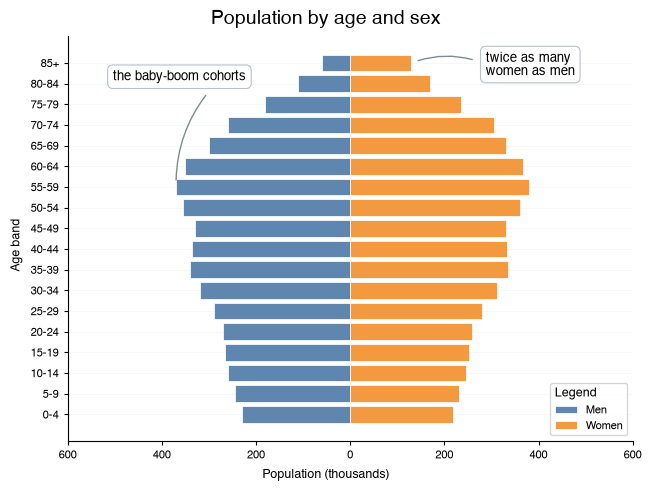

In [16]:
PyramidChart(
    data=[men, women],
    subtitle=SIDES,
    show_legend=True,
    legend={"location": LEGEND_LOCATION.LOWER_RIGHT},
    # two notes pinned to the axes, each pointing at a bar
    texts=[
        {
            "text": "the baby-boom cohorts",
            "x": 0.08,
            "y": 0.9,
            "coords": "axes",
            "target": (-MEN[11], 11),
        },
        {
            "text": "twice as many\nwomen as men",
            "x": 0.74,
            "y": 0.93,
            "coords": "axes",
            "target": (WOMEN[17], 17),
        },
    ],
    title="Population by age and sex",
    xlabel="Population (thousands)",
    ylabel="Age band",
).show()

## Multiple Pyramid Charts

One `PyramidChart` call draws one pyramid, and its two sides are the whole of its data. To compare pyramids, compose the rendered figures with [Grid](../../utility/grid/): each pyramid keeps its mirrored value axis inside its own cell, and a shared `xmax` puts them on the same scale. A pyramid cannot take part in a [Panel](../../utility/panel/), which overlays figures on one value axis; unmirrored data on a mirrored axis would mislead, so `Panel` raises a `ValueError` for it.

`men_2050` and `women_2050`, defined in a hidden cell, hold an illustrative projection of the same population 25 years on: every cohort alive today moves up five bands with a survival rate applied, and the five youngest bands are children not yet born. Side by side, the pyramids show the baby-boom bulge moving from the working ages into the oldest bands. `Grid` takes one `xlabel` and `ylabel` for all its cells.

In [17]:
# an illustrative 2050 projection: today's cohorts moved up five bands with survival applied,
# the five youngest bands not yet born; `yerr` is the half-width of the projection interval
MEN_2050 = [200, 205, 210, 218, 226, 228, 243, 257, 262, 266, 284, 310, 324, 310, 290, 285, 250, 255]
WOMEN_2050 = [190, 195, 200, 207, 215, 217, 231, 246, 251, 257, 278, 309, 330, 325, 320, 330, 315, 420]
# unborn cohorts are the most uncertain; among the living, uncertainty grows with age
ERR_2050 = [40, 36, 32, 27, 22, 6, 6, 6, 7, 7, 8, 9, 10, 12, 14, 17, 20, 28]

men_2050 = [
    {"label": band, "y": count, "yerr": error}
    for band, count, error in zip(AGE_BANDS, MEN_2050, ERR_2050)
]
women_2050 = [
    {"label": band, "y": count, "yerr": error}
    for band, count, error in zip(AGE_BANDS, WOMEN_2050, ERR_2050)
]

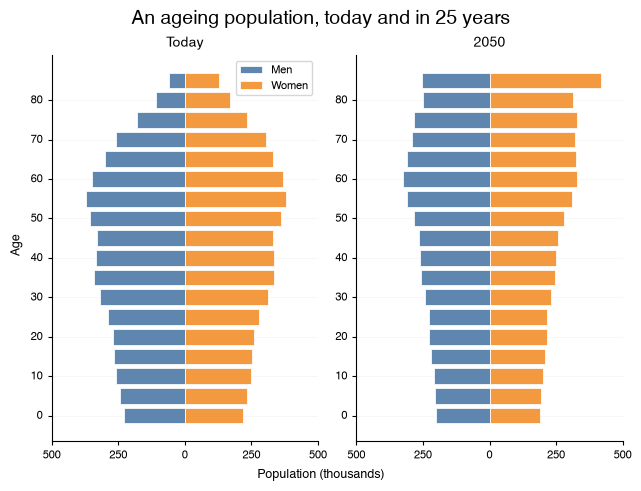

In [18]:
from datachart.utils import Grid

DECADES = {"yticks": list(range(0, 18, 2)), "yticklabels": [str(age) for age in range(0, 90, 10)]}
# the same value range in every cell, so the bars compare across the cells
AXIS_SCALE = {"xmax": 500, "xticks": [0, 250, 500]}

Grid(
    [
        PyramidChart(
            data=[men, women],
            subtitle=SIDES,
            title="Today",
            # the legend once, in the empty upper-right corner, without a title
            show_legend=True,
            legend={"title": "", "location": LEGEND_LOCATION.UPPER_RIGHT},
            **AXIS_SCALE,
            **DECADES,
        ),
        PyramidChart(data=[men_2050, women_2050], subtitle=SIDES, title="2050", **AXIS_SCALE, **DECADES),
    ],
    title="An ageing population, today and in 25 years",
    # one pair of axis labels for the whole grid
    xlabel="Population (thousands)",
    ylabel="Age",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

## Additional Features

### Error bars

A projection is an estimate, and an estimate should show how sure it is. Each data point carries its uncertainty as `yerr`, `show_yerr` draws it as a whisker along the value axis at the end of the bar, and the `plot_bar_error_color` style attribute colors the whiskers. On the 2050 projection the whiskers say where the uncertainty lives: the five youngest bands are children not yet born, whose number depends on future births, so their intervals are wide; the cohorts alive today are known, and their intervals grow only with the mortality of old age.

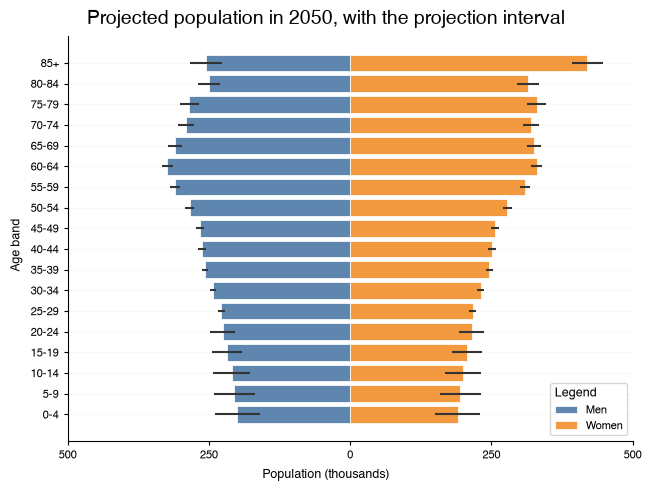

In [19]:
PyramidChart(
    data=[men_2050, women_2050],
    subtitle=SIDES,
    show_legend=True,
    # the oldest bars fill the top corners
    legend={"location": LEGEND_LOCATION.LOWER_RIGHT},
    # the color of the whiskers
    style={"plot_bar_error_color": "#333333"},
    title="Projected population in 2050, with the projection interval",
    xlabel="Population (thousands)",
    ylabel="Age band",
    **AXIS_SCALE,
    # draw the error bars
    show_yerr=True,
).show()

### Date labels

The categories of a pyramid are not always age bands; arrivals against departures by hour, or births against deaths by month, are pyramids too. A `label` that is a real temporal object (`datetime`, `date`, `numpy.datetime64` or a pandas `Timestamp`) keeps its categorical position but prints through `yticks_format`, a [DATE_FORMAT](../../../references/constants/#datachart.constants.DATE_FORMAT) member or any `strftime` pattern, so the tick labels come out tidy without hand-writing them. `entries` and `exits`, defined in a hidden cell, hold the illustrative passengers entering and leaving a commuter station in each hour from 06:00 to 22:00, labeled by the start of the hour; `DATE_FORMAT.TIME` prints the labels as clock times.

In [20]:
from datetime import datetime

# illustrative passengers entering and leaving a commuter station, per hour from 06:00 to 22:00
HOURS = [datetime(2024, 3, 12, hour) for hour in range(6, 23)]
ENTRIES = [120, 640, 1450, 780, 360, 300, 380, 420, 380, 360, 520, 760, 690, 420, 260, 180, 110]
EXITS = [80, 210, 520, 690, 360, 320, 400, 380, 340, 380, 640, 1380, 1120, 560, 300, 200, 140]

entries = [{"label": hour, "y": count} for hour, count in zip(HOURS, ENTRIES)]
exits = [{"label": hour, "y": count} for hour, count in zip(HOURS, EXITS)]

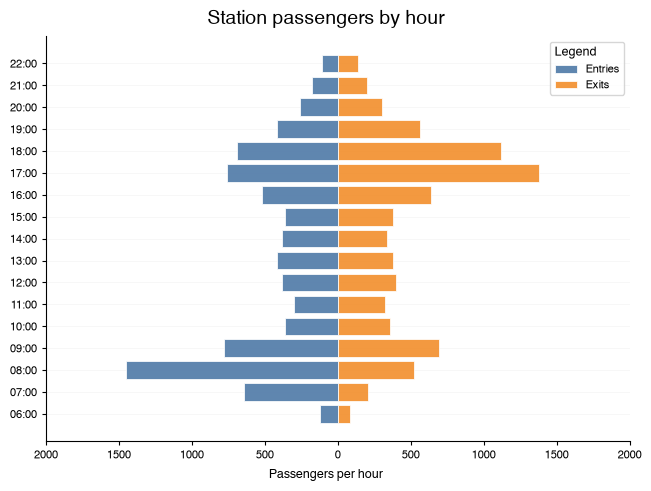

In [21]:
from datachart.constants import DATE_FORMAT

PyramidChart(
    data=[entries, exits],
    subtitle=["Entries", "Exits"],
    show_legend=True,
    title="Station passengers by hour",
    xlabel="Passengers per hour",
    # print the datetime labels as clock times
    yticks_format=DATE_FORMAT.TIME,
).show()

### Custom data keys

Census tables come as one row per age band with a column per sex, not as two lists of `label` and `y` points, and reshaping them just to plot is a chore. Instead, tell `PyramidChart` which keys to read: `label`, `y` and `yerr` take one key name for both sides or a list of two, one per side. With a list, the same records can serve as both sides, each side reading its own column. `census_rows` stores the population the way a census table would:

In [22]:
census_rows = [
    {"age_band": band, "men": men_count, "women": women_count}
    for band, men_count, women_count in zip(AGE_BANDS, MEN, WOMEN)
]
census_rows[:2]

[{'age_band': '0-4', 'men': 230, 'women': 218},
 {'age_band': '5-9', 'men': 245, 'women': 232}]

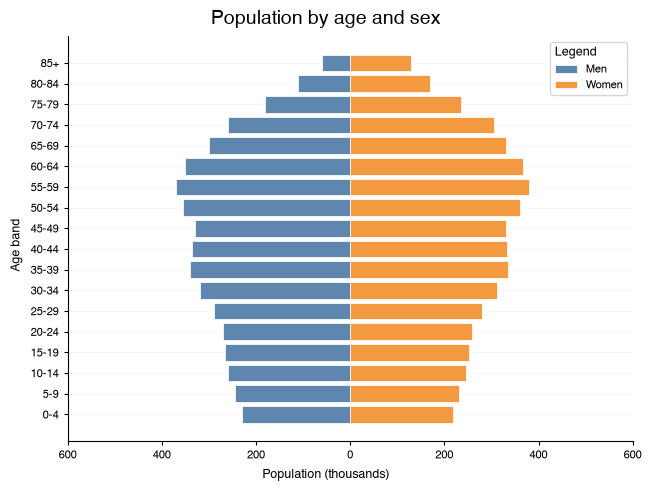

In [23]:
PyramidChart(
    # the same rows on both sides, each side reading its own column
    data=[census_rows, census_rows],
    label="age_band",
    y=["men", "women"],
    subtitle=SIDES,
    show_legend=True,
    title="Population by age and sex",
    xlabel="Population (thousands)",
    ylabel="Age band",
).show()

## Real-World Examples

The examples below put the features above to work on realistic data, each one answering a question. The data lives in hidden cells; each example says what its data is and where it comes from.

### Example 1: How Big Is the Retirement Wave? (Emphasis Rule, Reference Line, and a Note)

The shared population has its three largest bands, 50-54 to 60-64, just below the retirement age, and the question a pension planner asks is how many people that is. An `emphasis_rule` picks every bar above 345 thousand, which are the six bars of those three bands, an `hlines` entry marks the retirement age they are about to cross, and a note gives the sum: about 2.2 million people, more than a fifth of the population, reaching 65 within fifteen years. Decade ticks keep the age axis quiet, and the shared `AXIS_SCALE` leaves room for the note.

In [24]:
# the population of the three baby-boom bands, 50-54 to 60-64 (indices 10 to 12), in thousands
BOOMERS = sum(MEN[10:13]) + sum(WOMEN[10:13])

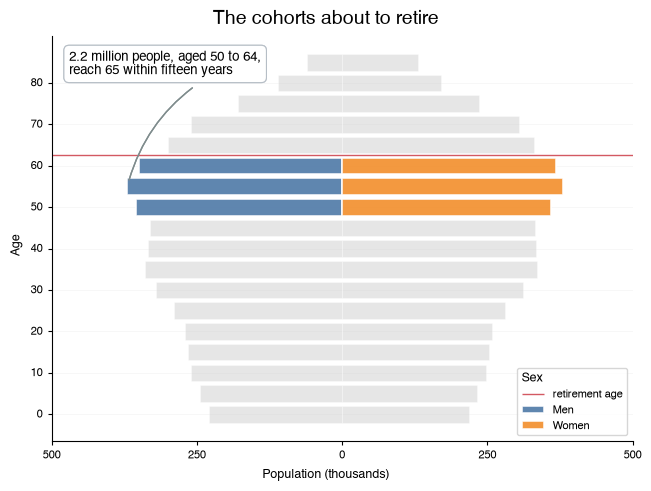

In [25]:
PyramidChart(
    data=[men, women],
    subtitle=SIDES,
    show_legend=True,
    legend={"title": "Sex", "location": LEGEND_LOCATION.LOWER_RIGHT},
    title="The cohorts about to retire",
    xlabel="Population (thousands)",
    ylabel="Age",
    **AXIS_SCALE,
    **DECADES,
    # the three largest bands, on both sides
    emphasis_rule={"above": 345},
    # the retirement age, between the 60-64 and 65-69 bands
    hlines=[{"y": 12.5, "label": "retirement age", "style": {"plot_hline_color": "#c1121f"}}, None],
    # the size of the wave
    texts={
        "text": f"{BOOMERS / 1000:.1f} million people, aged 50 to 64,\nreach 65 within fifteen years",
        "x": 0.03,
        "y": 0.93,
        "coords": "axes",
        "target": (-MEN[11], 11),
    },
).show()

### Example 2: When Does the Station Fill Up? (Time Labels, Reference Bands, and a Formatted Value Axis)

`entries` and `exits` are the illustrative hourly passenger counts of a commuter station from the [Date labels](#date-labels) section: people entering on the left, people leaving on the right. The question is when the platforms are busiest, and in which direction. The asymmetry answers it: the morning peak flows in and the evening peak flows out, which is the signature of a station in a residential district. Two `hspans` shade the rush hours, `yticks_format` prints the hours as clock times, and `xticks_format` puts a thousands separator on the value axis ([VALUE_FORMAT.THOUSANDS](../../../references/constants/#datachart.constants.VALUE_FORMAT)); the legend moves outside the axes, since both peaks reach into the corners.

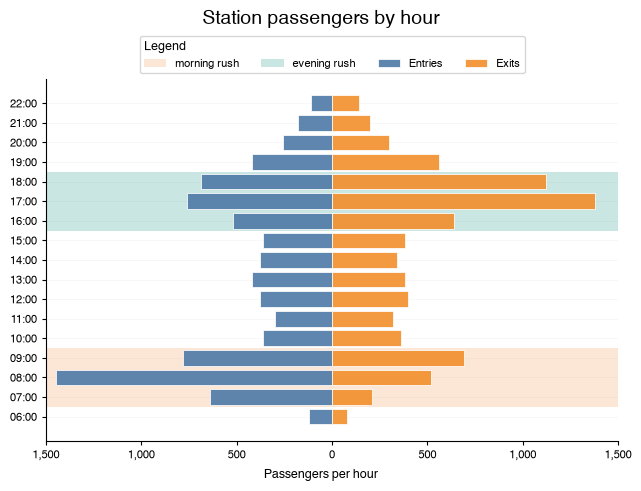

In [26]:
PyramidChart(
    data=[entries, exits],
    subtitle=["Entries", "Exits"],
    show_legend=True,
    legend={"location": LEGEND_LOCATION.OUTSIDE_TOP, "ncols": 4},
    # the rush hours: 07:00 to 09:59 (indices 1 to 3) and 16:00 to 18:59 (indices 10 to 12)
    hspans=[
        {"ymin": 0.5, "ymax": 3.5, "label": "morning rush", "style": {"plot_hspan_color": "#f4a261", "plot_hspan_alpha": 0.25}},
        {"ymin": 9.5, "ymax": 12.5, "label": "evening rush", "style": {"plot_hspan_color": "#2a9d8f", "plot_hspan_alpha": 0.25}},
    ],
    title="Station passengers by hour",
    xlabel="Passengers per hour",
    xmax=1500,
    xticks=[0, 500, 1000, 1500],
    xticks_format=VALUE_FORMAT.THOUSANDS,
    yticks_format=DATE_FORMAT.TIME,
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### Example 3: Young, Stationary, or Ageing? (Shares, a Shared Value Axis, and a Grid)

Demographers sort populations by the shape of their pyramid: expansive (a wide base of children and a narrow top), stationary (straight sides, each cohort about as large as the one before), and constrictive (a base narrower than the middle, the shape of an ageing population). `young` and `stationary`, defined in a hidden cell, are two illustrative populations of the first two shapes, generated from a small cohort model (a birth rate, a life expectancy that is five years longer for women, and a logistic survival curve); `ageing` is the shared population. All three are expressed as the share of the total population in each band, in percent, so countries of any size compare, and a shared `xmax` puts the three cells of the [Grid](../../utility/grid/) on the same scale: the widest bars of the young population are twice the widest bars of the other two.

In [27]:
import math


def cohort_model(growth, life_expectancy, spread):
    # the share of the population in each band, by sex, from a birth rate and a survival curve
    sides = []
    for extra_years, births in ((0, 1.05), (5, 1.0)):
        counts = []
        for index in range(18):
            age = 5 * index + 2.5 if index < 17 else 90
            survival = 1 / (1 + math.exp((age - life_expectancy - extra_years) / spread))
            counts.append(births * math.exp(-growth * age) * survival)
        sides.append(counts)
    total = sum(sides[0]) + sum(sides[1])
    return [
        [{"label": band, "y": round(100 * count / total, 2)} for band, count in zip(AGE_BANDS, side)]
        for side in sides
    ]


# a fast-growing population (2.8 % a year) with a short life expectancy, and a stationary one
young = cohort_model(growth=0.028, life_expectancy=68, spread=8)
stationary = cohort_model(growth=0.004, life_expectancy=78, spread=7)

# the shared population as shares of its total
TOTAL = sum(MEN) + sum(WOMEN)
ageing = [
    [{"label": band, "y": round(100 * count / TOTAL, 2)} for band, count in zip(AGE_BANDS, counts)]
    for counts in (MEN, WOMEN)
]

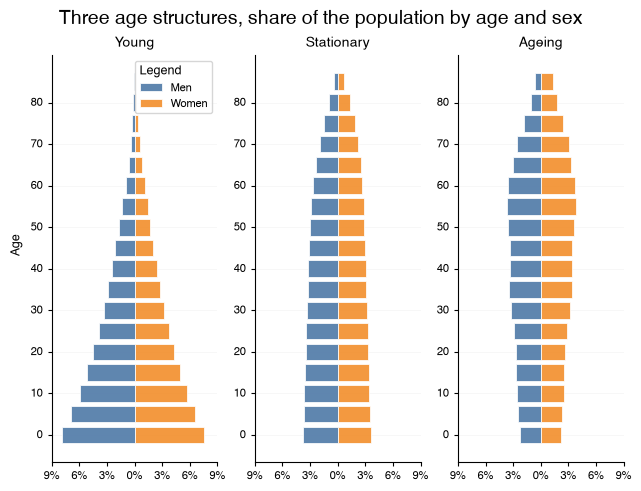

In [28]:
SHAPES = [("Young", young), ("Stationary", stationary), ("Ageing", ageing)]

Grid(
    [
        [
            PyramidChart(
                data=data,
                subtitle=SIDES,
                title=shape,
                # the same value axis in every cell, in percent of the population
                xmax=9,
                xticks=[0, 3, 6, 9],
                xticks_format="{x:.0f}%",
                # the legend once, in the empty corner of the first cell
                show_legend=(shape == "Young"),
                legend={"location": LEGEND_LOCATION.UPPER_RIGHT},
                **DECADES,
            )
            for shape, data in SHAPES
        ]
    ],
    title="Three age structures, share of the population by age and sex",
    ylabel="Age",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()